#### Data Dictionary:
###### There are two csv files given
###### train_1.csv: In the csv file, each row corresponds to a particular article and each column corresponds to a particular date. The values are the number of visits on that date.
###### The page name contains data in this format:
###### SPECIFIC NAME _ LANGUAGE.wikipedia.org _ ACCESS TYPE _ ACCESS ORIGIN
###### having information about the page name, the main domain, the device type used to access the page, and also the request origin(spider or browser agent)
###### Exog_Campaign_eng: This file contains data for the dates which had a campaign or significant event that could affect the views for that day. The data is just for pages in English.
###### There’s 1 for dates with campaigns and 0 for remaining dates. It is to be treated as an exogenous variable for models when training and forecasting data for pages in English

In [602]:
import numpy as np
import pandas as pd
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.core.pylabtools import figsize
from matplotlib.pyplot import title
from scipy.stats import alpha

warnings.filterwarnings('ignore')

In [603]:
df = pd.read_csv('/Users/farazahmed/Downloads/train_1.csv')

In [604]:
df.head()

,Page,2015-07-01,2015-07-02,2015-07-03,2015-07-04,2015-07-05,2015-07-06,2015-07-07,2015-07-08,2015-07-09,...,2016-12-22,2016-12-23,2016-12-24,2016-12-25,2016-12-26,2016-12-27,2016-12-28,2016-12-29,2016-12-30,2016-12-31
0,2NE1_zh.wikipedia.org_all-access_spider,18.0,11.0,5.0,13.0,14.0,9.0,9.0,22.0,26.0,...,32.0,63.0,15.0,26.0,14.0,20.0,22.0,19.0,18.0,20.0
1,2PM_zh.wikipedia.org_all-access_spider,11.0,14.0,15.0,18.0,11.0,13.0,22.0,11.0,10.0,...,17.0,42.0,28.0,15.0,9.0,30.0,52.0,45.0,26.0,20.0
2,3C_zh.wikipedia.org_all-access_spider,1.0,0.0,1.0,1.0,0.0,4.0,0.0,3.0,4.0,...,3.0,1.0,1.0,7.0,4.0,4.0,6.0,3.0,4.0,17.0
3,4minute_zh.wikipedia.org_all-access_spider,35.0,13.0,10.0,94.0,4.0,26.0,14.0,9.0,11.0,...,32.0,10.0,26.0,27.0,16.0,11.0,17.0,19.0,10.0,11.0
4,52_Hz_I_Love_You_zh.wikipedia.org_all-access_s...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,48.0,9.0,25.0,13.0,3.0,11.0,27.0,13.0,36.0,10.0


In [605]:
df

,Page,2015-07-01,2015-07-02,2015-07-03,2015-07-04,2015-07-05,2015-07-06,2015-07-07,2015-07-08,2015-07-09,...,2016-12-22,2016-12-23,2016-12-24,2016-12-25,2016-12-26,2016-12-27,2016-12-28,2016-12-29,2016-12-30,2016-12-31
0,2NE1_zh.wikipedia.org_all-access_spider,18.0,11.0,5.0,13.0,14.0,9.0,9.0,22.0,26.0,...,32.0,63.0,15.0,26.0,14.0,20.0,22.0,19.0,18.0,20.0
1,2PM_zh.wikipedia.org_all-access_spider,11.0,14.0,15.0,18.0,11.0,13.0,22.0,11.0,10.0,...,17.0,42.0,28.0,15.0,9.0,30.0,52.0,45.0,26.0,20.0
2,3C_zh.wikipedia.org_all-access_spider,1.0,0.0,1.0,1.0,0.0,4.0,0.0,3.0,4.0,...,3.0,1.0,1.0,7.0,4.0,4.0,6.0,3.0,4.0,17.0
3,4minute_zh.wikipedia.org_all-access_spider,35.0,13.0,10.0,94.0,4.0,26.0,14.0,9.0,11.0,...,32.0,10.0,26.0,27.0,16.0,11.0,17.0,19.0,10.0,11.0
4,52_Hz_I_Love_You_zh.wikipedia.org_all-access_s...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,48.0,9.0,25.0,13.0,3.0,11.0,27.0,13.0,36.0,10.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145058,Underworld_(serie_de_películas)_es.wikipedia.o...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,13.0,12.0,13.0,3.0,5.0,10.0
145059,Resident_Evil:_Capítulo_Final_es.wikipedia.org...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
145060,Enamorándome_de_Ramón_es.wikipedia.org_all-acc...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
145061,Hasta_el_último_hombre_es.wikipedia.org_all-ac...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#### Treating 'Null values'.
1. ##### We drop the rows that have all values as 'nan'.

2. ##### We then also drop rows that have nan more than 300 days, because the time series for that would not make much sense

3. ##### We fill all the remaining values with zero assuming there was no traffic on the date that the values are nan for.

In [606]:
print(df.shape)
df=df.dropna(how='all')
#‘all’ : If all values are NA, drop that row or column.
print(df.shape)

(145063, 551)
(145063, 551)


In [607]:
df=df.dropna(thresh=300)
print(df.shape)
df=df.fillna(0)
df.tail()

(133617, 551)


,Page,2015-07-01,2015-07-02,2015-07-03,2015-07-04,2015-07-05,2015-07-06,2015-07-07,2015-07-08,2015-07-09,...,2016-12-22,2016-12-23,2016-12-24,2016-12-25,2016-12-26,2016-12-27,2016-12-28,2016-12-29,2016-12-30,2016-12-31
145012,Legión_(Marvel_Comics)_es.wikipedia.org_all-ac...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,7.0,3.0,2.0,4.0,2.0,4.0,4.0,1.0,2.0,2.0
145013,Referéndum_sobre_la_permanencia_del_Reino_Unid...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,9.0,16.0,8.0,3.0,6.0,3.0,3.0,10.0,11.0,3.0
145014,Salida_del_Reino_Unido_de_la_Unión_Europea_es....,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,29.0,36.0,23.0,182.0,43.0,8.0,22.0,13.0,18.0,14.0
145015,"Amar,_después_de_amar_es.wikipedia.org_all-acc...",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,7.0,30.0,27.0,14.0,8.0,7.0,5.0,43.0,12.0,25.0
145016,Anexo:89.º_Premios_Óscar_es.wikipedia.org_all-...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0


In [608]:
def extract_parts(page_name):
    """
    Extracts the parts of the page name.

    Returns title, language, access type, and access origin
    as independent variables, for making new columns.
    """
    parts = page_name.rsplit('_', 3)
    title = parts[0]
    language = parts[1].split('.')[0]
    access_type = parts[2]
    access_origin = parts[3]
    return title, language, access_type, access_origin

In [609]:
# Making new columns

df[['title', 'language', 'access_type', 'access_origin']] = df['Page'].apply(lambda x: pd.Series(extract_parts(x)))

In [610]:
df = df.set_index(['title', 'language', 'access_type', 'access_origin']).reset_index()
df

,title,language,access_type,access_origin,Page,2015-07-01,2015-07-02,2015-07-03,2015-07-04,2015-07-05,...,2016-12-22,2016-12-23,2016-12-24,2016-12-25,2016-12-26,2016-12-27,2016-12-28,2016-12-29,2016-12-30,2016-12-31
0,2NE1,zh,all-access,spider,2NE1_zh.wikipedia.org_all-access_spider,18.0,11.0,5.0,13.0,14.0,...,32.0,63.0,15.0,26.0,14.0,20.0,22.0,19.0,18.0,20.0
1,2PM,zh,all-access,spider,2PM_zh.wikipedia.org_all-access_spider,11.0,14.0,15.0,18.0,11.0,...,17.0,42.0,28.0,15.0,9.0,30.0,52.0,45.0,26.0,20.0
2,3C,zh,all-access,spider,3C_zh.wikipedia.org_all-access_spider,1.0,0.0,1.0,1.0,0.0,...,3.0,1.0,1.0,7.0,4.0,4.0,6.0,3.0,4.0,17.0
3,4minute,zh,all-access,spider,4minute_zh.wikipedia.org_all-access_spider,35.0,13.0,10.0,94.0,4.0,...,32.0,10.0,26.0,27.0,16.0,11.0,17.0,19.0,10.0,11.0
4,5566,zh,all-access,spider,5566_zh.wikipedia.org_all-access_spider,12.0,7.0,4.0,5.0,20.0,...,16.0,27.0,8.0,17.0,32.0,19.0,23.0,17.0,17.0,50.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
133612,Legión_(Marvel_Comics),es,all-access,spider,Legión_(Marvel_Comics)_es.wikipedia.org_all-ac...,0.0,0.0,0.0,0.0,0.0,...,7.0,3.0,2.0,4.0,2.0,4.0,4.0,1.0,2.0,2.0
133613,Referéndum_sobre_la_permanencia_del_Reino_Unid...,es,all-access,spider,Referéndum_sobre_la_permanencia_del_Reino_Unid...,0.0,0.0,0.0,0.0,0.0,...,9.0,16.0,8.0,3.0,6.0,3.0,3.0,10.0,11.0,3.0
133614,Salida_del_Reino_Unido_de_la_Unión_Europea,es,all-access,spider,Salida_del_Reino_Unido_de_la_Unión_Europea_es....,0.0,0.0,0.0,0.0,0.0,...,29.0,36.0,23.0,182.0,43.0,8.0,22.0,13.0,18.0,14.0
133615,"Amar,_después_de_amar",es,all-access,spider,"Amar,_después_de_amar_es.wikipedia.org_all-acc...",0.0,0.0,0.0,0.0,0.0,...,7.0,30.0,27.0,14.0,8.0,7.0,5.0,43.0,12.0,25.0


In [611]:
df.drop('Page', axis=1, inplace=True)

In [612]:
df

,title,language,access_type,access_origin,2015-07-01,2015-07-02,2015-07-03,2015-07-04,2015-07-05,2015-07-06,...,2016-12-22,2016-12-23,2016-12-24,2016-12-25,2016-12-26,2016-12-27,2016-12-28,2016-12-29,2016-12-30,2016-12-31
0,2NE1,zh,all-access,spider,18.0,11.0,5.0,13.0,14.0,9.0,...,32.0,63.0,15.0,26.0,14.0,20.0,22.0,19.0,18.0,20.0
1,2PM,zh,all-access,spider,11.0,14.0,15.0,18.0,11.0,13.0,...,17.0,42.0,28.0,15.0,9.0,30.0,52.0,45.0,26.0,20.0
2,3C,zh,all-access,spider,1.0,0.0,1.0,1.0,0.0,4.0,...,3.0,1.0,1.0,7.0,4.0,4.0,6.0,3.0,4.0,17.0
3,4minute,zh,all-access,spider,35.0,13.0,10.0,94.0,4.0,26.0,...,32.0,10.0,26.0,27.0,16.0,11.0,17.0,19.0,10.0,11.0
4,5566,zh,all-access,spider,12.0,7.0,4.0,5.0,20.0,8.0,...,16.0,27.0,8.0,17.0,32.0,19.0,23.0,17.0,17.0,50.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
133612,Legión_(Marvel_Comics),es,all-access,spider,0.0,0.0,0.0,0.0,0.0,0.0,...,7.0,3.0,2.0,4.0,2.0,4.0,4.0,1.0,2.0,2.0
133613,Referéndum_sobre_la_permanencia_del_Reino_Unid...,es,all-access,spider,0.0,0.0,0.0,0.0,0.0,0.0,...,9.0,16.0,8.0,3.0,6.0,3.0,3.0,10.0,11.0,3.0
133614,Salida_del_Reino_Unido_de_la_Unión_Europea,es,all-access,spider,0.0,0.0,0.0,0.0,0.0,0.0,...,29.0,36.0,23.0,182.0,43.0,8.0,22.0,13.0,18.0,14.0
133615,"Amar,_después_de_amar",es,all-access,spider,0.0,0.0,0.0,0.0,0.0,0.0,...,7.0,30.0,27.0,14.0,8.0,7.0,5.0,43.0,12.0,25.0


In [613]:
df['title'].nunique()

44491

In [614]:
df['language'].nunique()

9

In [615]:
df['access_type'].nunique()

3

In [616]:
df['access_origin'].nunique()

2

#### Exploratory data analysis

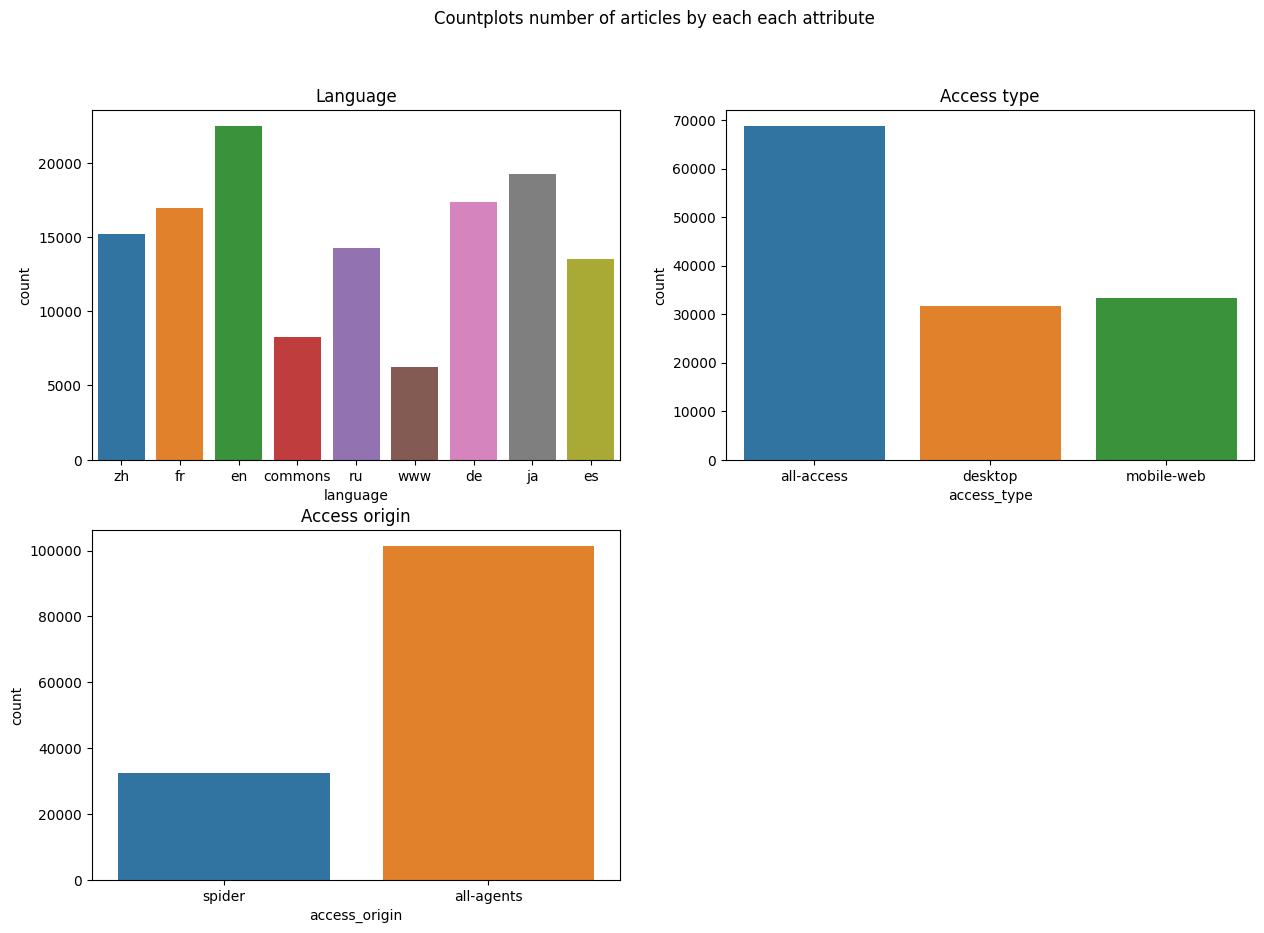

In [617]:
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(15, 10))
plt.suptitle('Countplots number of articles by each each attribute')

sns.countplot(data=df, x='language', ax=ax[0, 0], hue='language')
ax[0,0].set_title('Language')

sns.countplot(data=df, x='access_type', ax=ax[0, 1], hue='access_type')
ax[0,1].set_title('Access type')

sns.countplot(data=df, x='access_origin', ax=ax[1, 0], hue='access_origin')
ax[1,0].set_title('Access origin')

ax[1,1].axis('off')
plt.show()

In [618]:
# Grouping by language and aggregating on mean visits for each day.

exclude_cols = ['title', 'language', 'access_type', 'access_origin']

df_temp = df.groupby('language').agg({col: 'mean' for col in df.columns if col not in exclude_cols})
df_temp

,2015-07-01,2015-07-02,2015-07-03,2015-07-04,2015-07-05,2015-07-06,2015-07-07,2015-07-08,2015-07-09,2015-07-10,...,2016-12-22,2016-12-23,2016-12-24,2016-12-25,2016-12-26,2016-12-27,2016-12-28,2016-12-29,2016-12-30,2016-12-31
language,,,,,,,,,,,,,,,,,,,,,
commons,137.917614,142.449189,139.099685,115.011493,127.912896,145.855311,152.569320,168.919913,146.516453,140.302565,...,199.363174,219.913501,173.677595,188.996734,228.720300,237.444108,228.058190,227.904065,227.333777,195.896564
de,763.765926,753.362861,723.074415,663.537323,771.358657,849.080636,823.422532,835.455305,804.329513,749.593653,...,862.566755,872.653899,850.650443,1312.415102,1260.964290,1119.596936,1062.284069,1033.939062,981.786430,937.842875
en,3767.328604,3755.158765,3565.225696,3711.782932,3833.433025,4127.429067,3906.341724,3685.854621,3771.183714,3749.860313,...,5191.453438,4850.360002,5162.438451,5360.667704,6036.850129,6314.335275,6108.874144,6518.058525,5401.792360,5280.643467
es,1127.485204,1077.485425,990.895949,930.303151,1011.759575,1153.091801,1123.942440,1090.832190,1070.245812,972.952328,...,931.332891,877.420486,840.156077,862.085529,1142.166556,1070.923400,1108.996753,1058.660320,807.551177,776.934322
fr,499.092872,502.297852,483.007553,516.275785,506.871666,528.072752,510.426481,501.033632,495.848124,467.943179,...,658.231414,644.305818,622.796082,672.201204,903.697368,840.590217,783.585379,763.209169,710.502773,654.060656
ja,614.637160,705.813216,637.451671,800.897435,768.352319,669.544493,651.298938,647.372428,631.090645,655.678362,...,687.559368,988.378855,869.984504,830.838974,795.836486,808.541436,807.430163,883.752786,979.278777,1228.720808
ru,663.199229,674.677015,625.329783,588.171829,626.385354,674.764681,659.297617,656.209530,672.200981,769.787596,...,908.778697,900.445550,889.133357,1128.097477,1131.580448,998.374071,945.054730,909.352207,815.475123,902.600210
www,56.036127,61.494701,52.223988,49.482177,54.235549,62.849550,69.478484,59.679351,53.176943,63.997913,...,51.962909,78.749037,72.972383,78.113198,44.341362,46.206326,112.867373,48.636159,61.438022,56.019428
zh,272.498521,272.906778,271.097167,273.712379,291.977713,293.490632,293.170337,300.824206,298.983433,310.819736,...,335.948130,328.966998,346.021103,364.817763,365.959372,363.066991,369.049701,340.526330,342.745316,352.184275


In [619]:
df_temp = df_temp.transpose()
df_temp

language,commons,de,en,es,fr,ja,ru,www,zh
2015-07-01,137.917614,763.765926,3767.328604,1127.485204,499.092872,614.637160,663.199229,56.036127,272.498521
2015-07-02,142.449189,753.362861,3755.158765,1077.485425,502.297852,705.813216,674.677015,61.494701,272.906778
2015-07-03,139.099685,723.074415,3565.225696,990.895949,483.007553,637.451671,625.329783,52.223988,271.097167
2015-07-04,115.011493,663.537323,3711.782932,930.303151,516.275785,800.897435,588.171829,49.482177,273.712379
2015-07-05,127.912896,771.358657,3833.433025,1011.759575,506.871666,768.352319,626.385354,54.235549,291.977713
...,...,...,...,...,...,...,...,...,...
2016-12-27,237.444108,1119.596936,6314.335275,1070.923400,840.590217,808.541436,998.374071,46.206326,363.066991
2016-12-28,228.058190,1062.284069,6108.874144,1108.996753,783.585379,807.430163,945.054730,112.867373,369.049701
2016-12-29,227.904065,1033.939062,6518.058525,1058.660320,763.209169,883.752786,909.352207,48.636159,340.526330
2016-12-30,227.333777,981.786430,5401.792360,807.551177,710.502773,979.278777,815.475123,61.438022,342.745316


In [620]:
df_temp.info()

<class 'pandas.core.frame.DataFrame'>
Index: 550 entries, 2015-07-01 to 2016-12-31
Data columns (total 9 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   commons  550 non-null    float64
 1   de       550 non-null    float64
 2   en       550 non-null    float64
 3   es       550 non-null    float64
 4   fr       550 non-null    float64
 5   ja       550 non-null    float64
 6   ru       550 non-null    float64
 7   www      550 non-null    float64
 8   zh       550 non-null    float64
dtypes: float64(9)
memory usage: 59.1+ KB


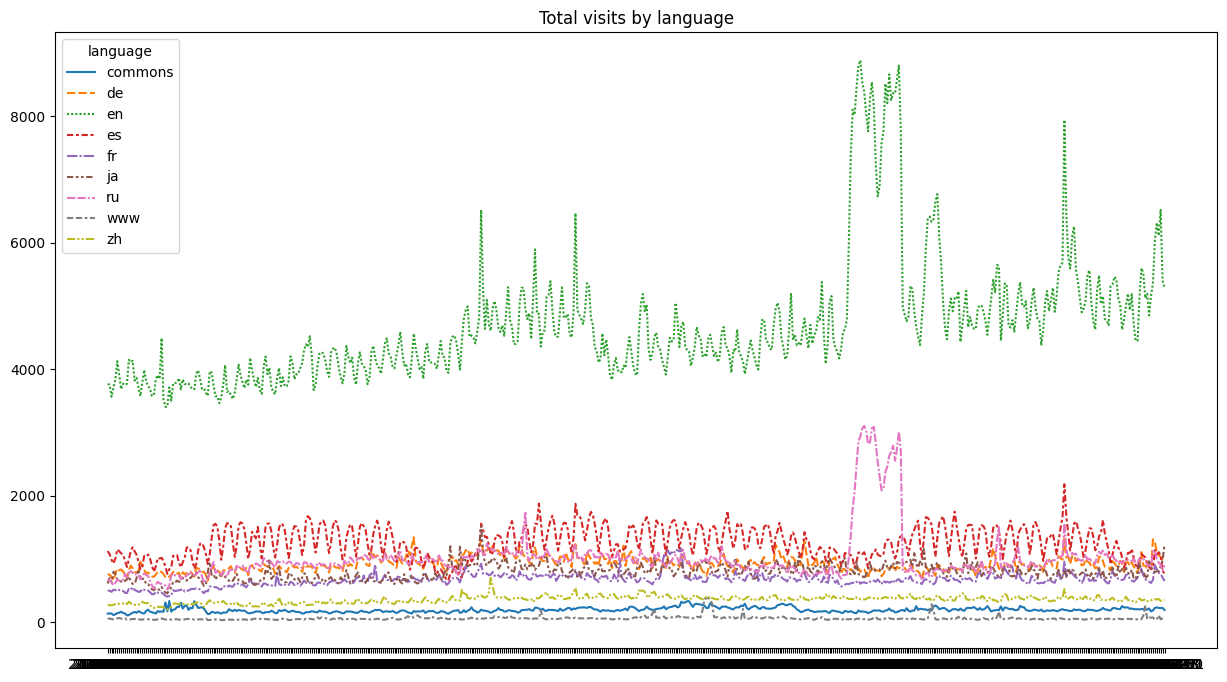

In [621]:
plt.figure(figsize=(15, 8))
sns.lineplot(data=df_temp)
plt.title('Total visits by language')
plt.show()

#### It is clear from the above graph that english has most number of visits.

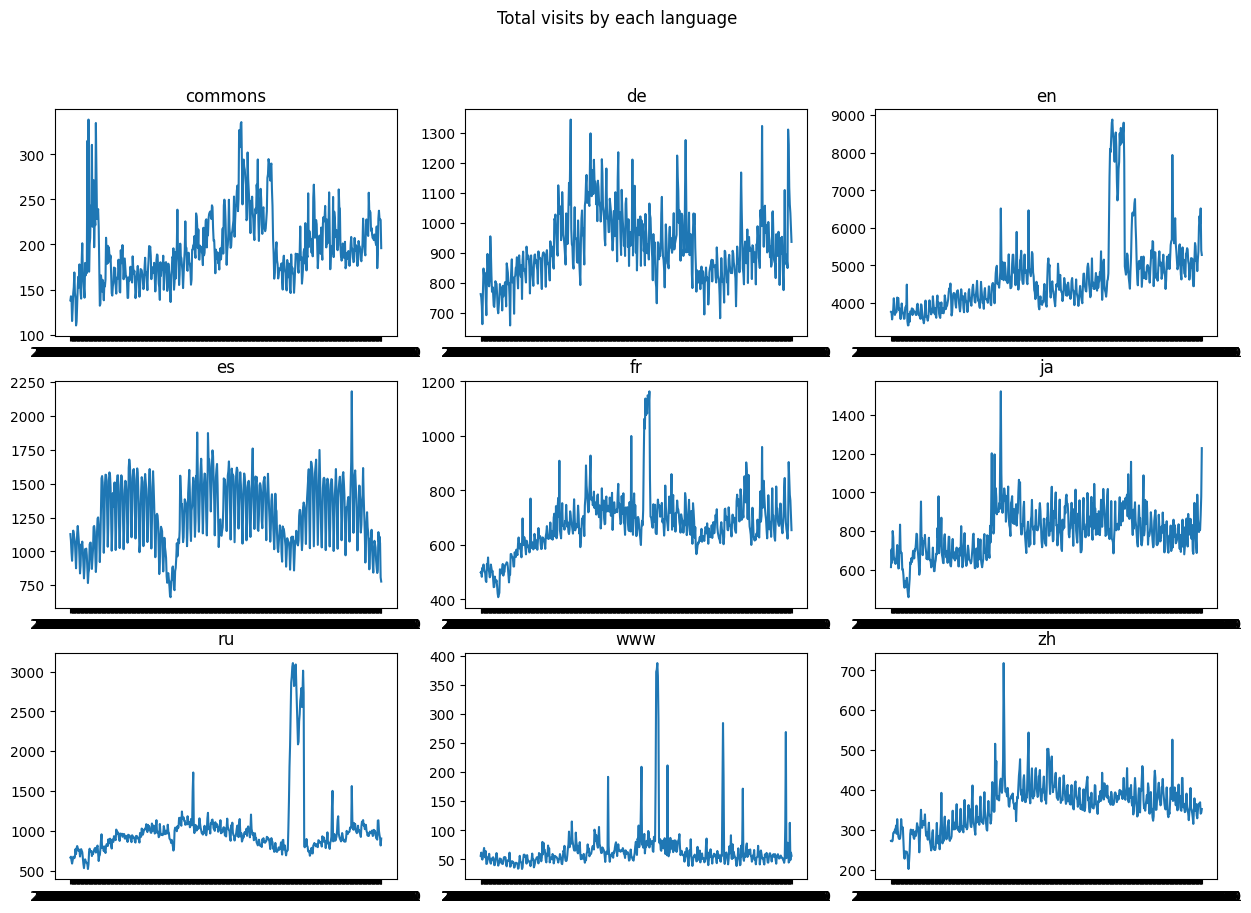

In [622]:
# Total visits for each language throughout the time range.

fig, ax = plt.subplots(nrows=3, ncols=3, figsize=(15, 10))
fig.suptitle('Total visits by each language')

ax[0, 0].plot(df_temp.index, df_temp['commons'])
ax[0, 0].set_title('commons')

ax[0, 1].plot(df_temp.index, df_temp['de'])
ax[0, 1].set_title('de')

ax[0, 2].plot(df_temp.index, df_temp['en'])
ax[0, 2].set_title('en')

ax[1, 0].plot(df_temp.index, df_temp['es'])
ax[1, 0].set_title('es')

ax[1, 1].plot(df_temp.index, df_temp['fr'])
ax[1, 1].set_title('fr')

ax[1, 2].plot(df_temp.index, df_temp['ja'])
ax[1, 2].set_title('ja')

ax[2, 0].plot(df_temp.index, df_temp['ru'])
ax[2, 0].set_title('ru')

ax[2, 1].plot(df_temp.index, df_temp['www'])
ax[2, 1].set_title('www')

ax[2, 2].plot(df_temp.index, df_temp['zh'])
ax[2, 2].set_title('zh')

plt.show()


In [623]:
# Comparing total visits by 'access_type'.

exclude_cols = ['title', 'language', 'access_type', 'access_origin']

df_temp1 = df.groupby('access_type').agg({col: 'mean' for col in df.columns if col not in exclude_cols})
df_temp1

,2015-07-01,2015-07-02,2015-07-03,2015-07-04,2015-07-05,2015-07-06,2015-07-07,2015-07-08,2015-07-09,2015-07-10,...,2016-12-22,2016-12-23,2016-12-24,2016-12-25,2016-12-26,2016-12-27,2016-12-28,2016-12-29,2016-12-30,2016-12-31
access_type,,,,,,,,,,,,,,,,,,,,,
all-access,1086.976687,1100.218924,1034.413065,1069.326406,1113.433263,1177.058616,1128.118761,1091.906356,1097.381443,1087.941675,...,1415.996973,1401.762333,1429.495649,1558.690489,1719.679807,1720.417722,1668.579819,1721.85829,1504.575977,1506.662577
desktop,1261.859494,1271.058956,1135.225823,1063.252310,1120.945285,1374.119937,1326.001361,1255.191044,1270.042532,1245.942215,...,1734.248671,1531.140032,1448.334272,1478.615380,1734.199051,1794.371772,1779.825918,1777.74019,1550.031741,1452.075475
mobile-web,1023.979129,1015.645935,1027.093516,1157.030181,1187.939518,1093.973813,1042.675756,1025.856692,1020.639329,1028.211478,...,1102.038019,1247.719211,1364.003243,1570.417760,1642.508033,1587.911979,1515.923932,1642.47617,1415.359050,1535.473378


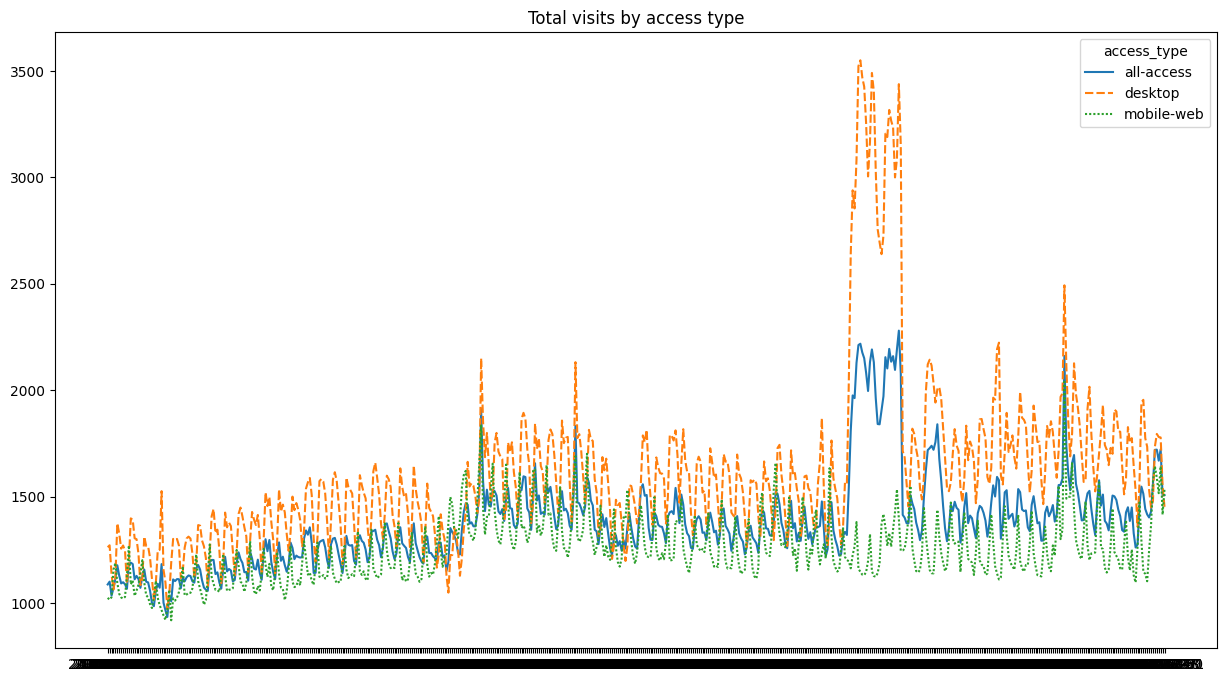

In [624]:
plt.figure(figsize=(15, 8))
sns.lineplot(data=df_temp1.transpose())
plt.title('Total visits by access type')
plt.show()

In [625]:
df_temp.reset_index(inplace=True)

In [626]:
df_temp.set_index('index', inplace=True)

In [627]:
df_temp

language,commons,de,en,es,fr,ja,ru,www,zh
index,,,,,,,,,
2015-07-01,137.917614,763.765926,3767.328604,1127.485204,499.092872,614.637160,663.199229,56.036127,272.498521
2015-07-02,142.449189,753.362861,3755.158765,1077.485425,502.297852,705.813216,674.677015,61.494701,272.906778
2015-07-03,139.099685,723.074415,3565.225696,990.895949,483.007553,637.451671,625.329783,52.223988,271.097167
2015-07-04,115.011493,663.537323,3711.782932,930.303151,516.275785,800.897435,588.171829,49.482177,273.712379
2015-07-05,127.912896,771.358657,3833.433025,1011.759575,506.871666,768.352319,626.385354,54.235549,291.977713
...,...,...,...,...,...,...,...,...,...
2016-12-27,237.444108,1119.596936,6314.335275,1070.923400,840.590217,808.541436,998.374071,46.206326,363.066991
2016-12-28,228.058190,1062.284069,6108.874144,1108.996753,783.585379,807.430163,945.054730,112.867373,369.049701
2016-12-29,227.904065,1033.939062,6518.058525,1058.660320,763.209169,883.752786,909.352207,48.636159,340.526330


#### As the maximum visits are observed for english language we will do further analysis for english only.

In [628]:
# Extracting visits for english.
english = df_temp['en']
english

index
2015-07-01    3767.328604
2015-07-02    3755.158765
2015-07-03    3565.225696
2015-07-04    3711.782932
2015-07-05    3833.433025
                 ...     
2016-12-27    6314.335275
2016-12-28    6108.874144
2016-12-29    6518.058525
2016-12-30    5401.792360
2016-12-31    5280.643467
Name: en, Length: 550, dtype: float64

In [629]:
# Rounding values to whole number.
english = english.apply(round)

In [630]:
# Reconverting back to panda series.
english = pd.DataFrame(english)
english

,en
index,
2015-07-01,3767
2015-07-02,3755
2015-07-03,3565
2015-07-04,3712
2015-07-05,3833
...,...
2016-12-27,6314
2016-12-28,6109
2016-12-29,6518


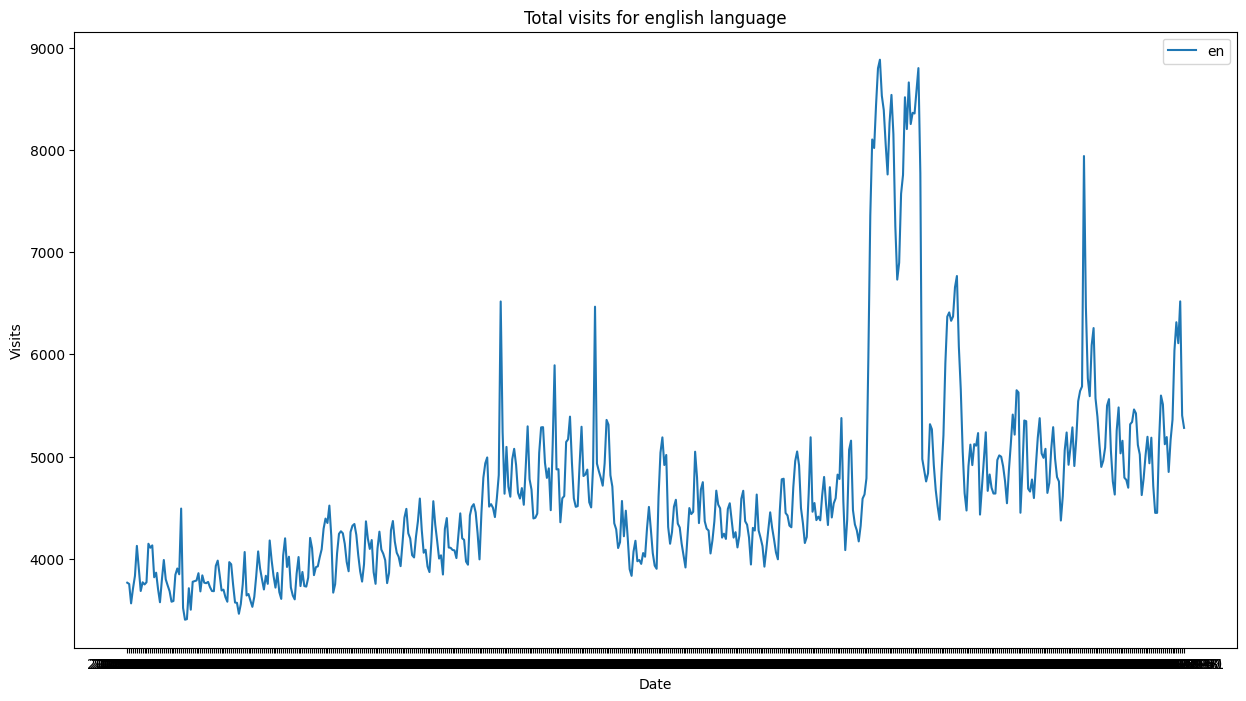

In [631]:
# Visualizing visits for english.

plt.figure(figsize=(15, 8))
sns.lineplot(english)
plt.xlabel('Date')
plt.ylabel('Visits')
plt.title('Total visits for english language')
plt.show()

#### Checking the stationarity of the dataset using Dickey-Fuller Test.
##### Here the null hypothesis is that the TS is non-stationary

In [632]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import (
    mean_squared_error as mse,
    mean_absolute_error as mae,
    mean_absolute_percentage_error as mape
)

In [633]:
def check_stationarity(data):
    """Inputs a time series, performs the Dickey-Fuller test and prints the results."""

    adfuller_result = adfuller(data)
    p_value = adfuller_result[1]
    if p_value < 0.05:
        print('The time series is stationary.')
    else:
        print('The time series is non-stationary.')

check_stationarity(english)

The time series is non-stationary.


In [634]:
ts_data = english['en']

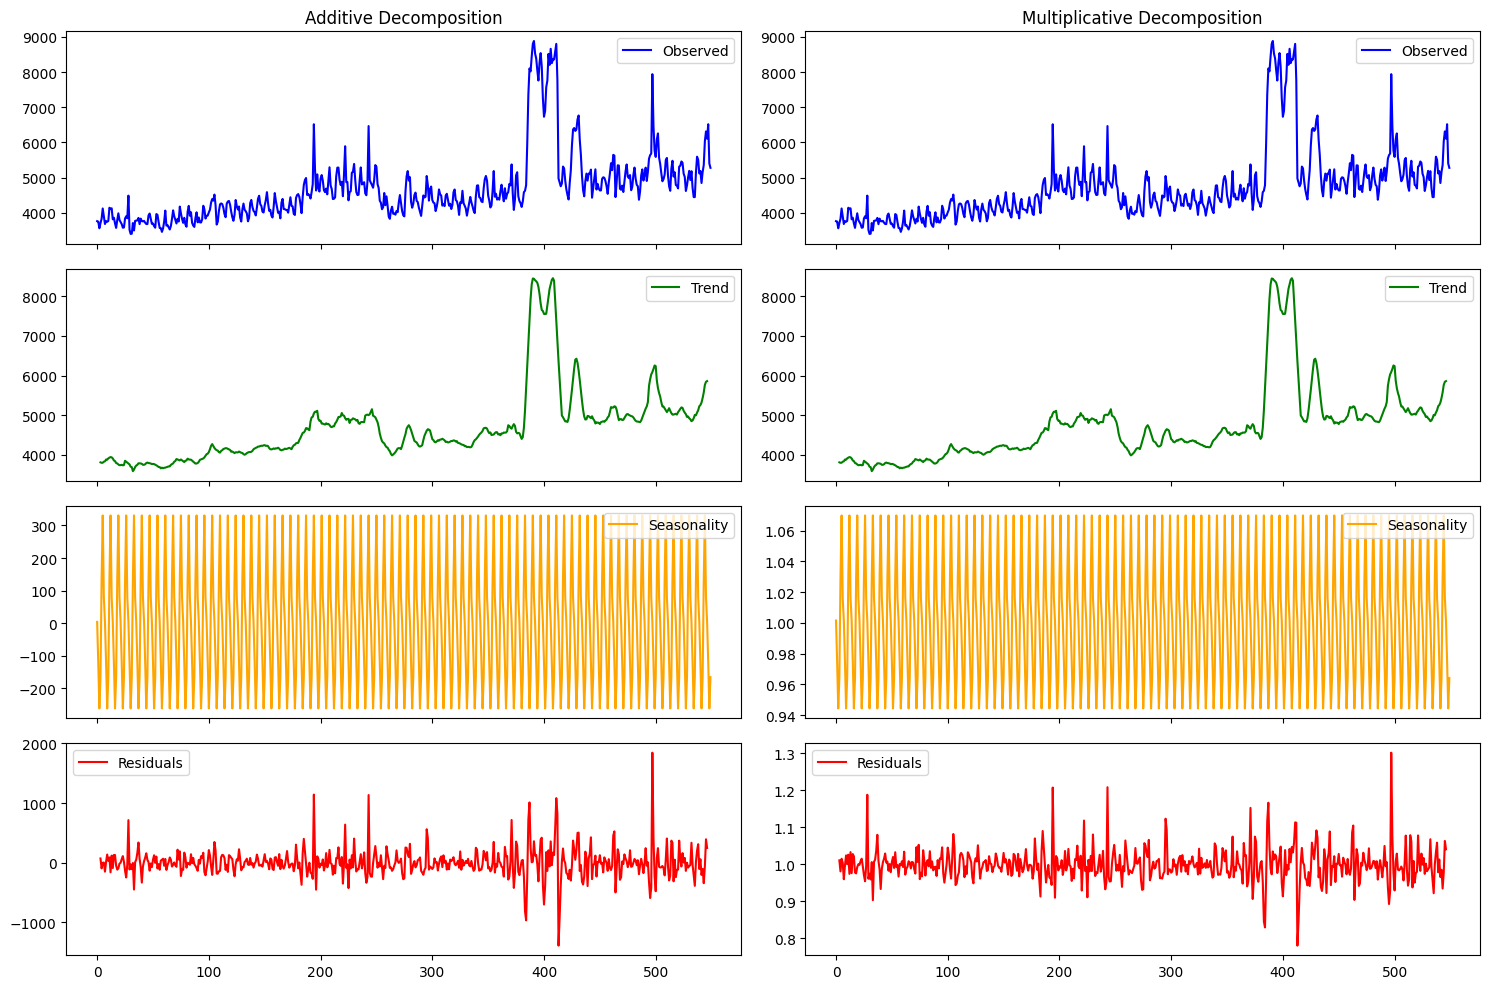

In [635]:
# Decomposing the time series for both 'additive' and 'multiplicative' models for comparison.

decomposition_add = seasonal_decompose(ts_data.values, period=7, model='additive')
decomposition_mul = seasonal_decompose(ts_data.values, period=7, model='multiplicative')

trend_additive, seasonal_additive, residual_additive = decomposition_add.trend, decomposition_add.seasonal, decomposition_add.resid
trend_mul, seasonal_mul, residual_mul = decomposition_mul.trend, decomposition_mul.seasonal, decomposition_mul.resid

fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(15, 10), sharex=True)

axes[0, 0].set_title("Additive Decomposition", fontsize=12)
axes[0, 1].set_title("Multiplicative Decomposition", fontsize=12)

axes[0, 0].plot(ts_data.values, label='Observed', color='blue')
axes[0, 0].legend(loc='best')

axes[0, 1].plot(ts_data.values, label='Observed', color='blue')
axes[0, 1].legend(loc='best')

axes[1, 0].plot(trend_additive, label='Trend', color='green')
axes[1, 0].legend(loc='best')

axes[1, 1].plot(trend_mul, label='Trend', color='green')
axes[1, 1].legend(loc='best')


axes[2, 0].plot(seasonal_additive, label='Seasonality', color='orange')
axes[2, 0].legend(loc='best')

axes[2, 1].plot(seasonal_mul, label='Seasonality', color='orange')
axes[2, 1].legend(loc='best')


axes[3, 0].plot(residual_additive, label='Residuals', color='red')
axes[3, 0].legend(loc='best')

axes[3, 1].plot(residual_mul, label='Residuals', color='red')
axes[3, 1].legend(loc='best')

plt.tight_layout()
plt.show()


##### We can see above that the additive model shows less variance implying that it fits the data better than the multiplicative model.

#### Removing the trend and seasonality with differencing

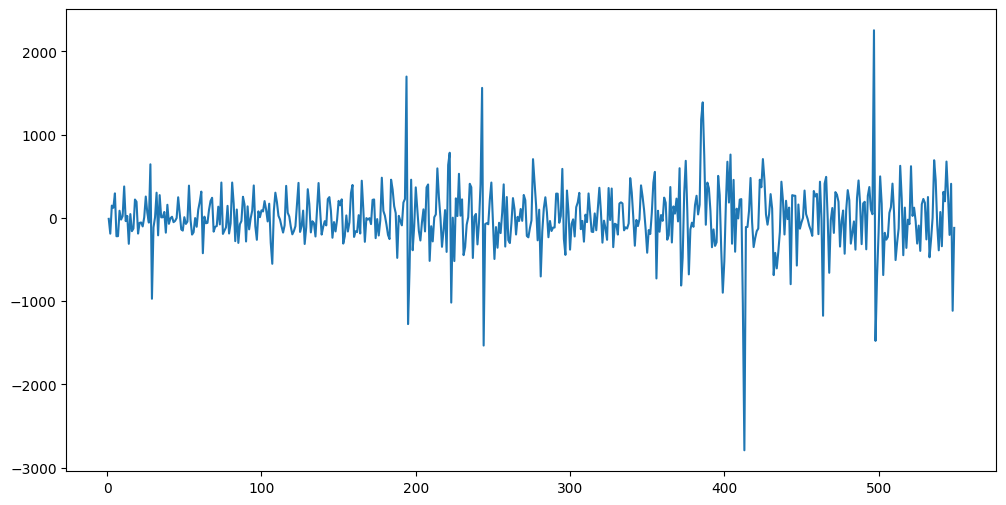

In [636]:
ts_diff = ts_data - ts_data.shift(1)
plt.figure(figsize=(12,6))
sns.lineplot(ts_diff.values)
plt.show()

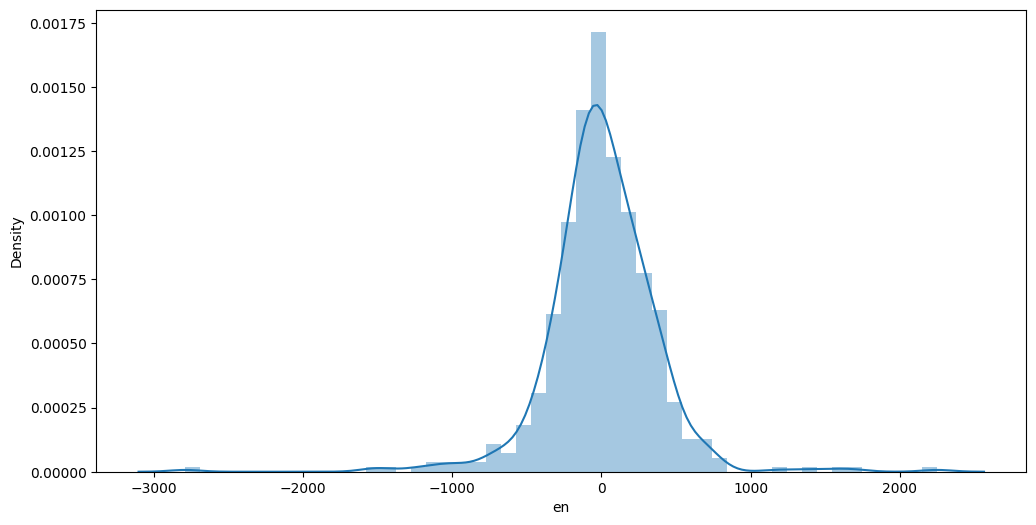

In [637]:
# Plotting the residuals to check for normality.
plt.figure(figsize=(12,6))
sns.distplot(ts_diff)
plt.show()

##### We can observe that the residuals are normally distributed which is what we want.

In [638]:
# Checking if differencing by one order removes stationarity.
ts_diff.dropna(inplace=True)
check_stationarity(ts_diff)

The time series is stationary.


#### Plotting ACF and PACF to decide [p, d, q] parameters for the ARIMA model.

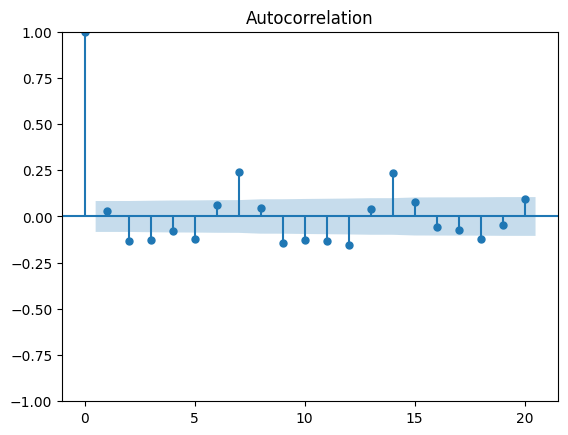

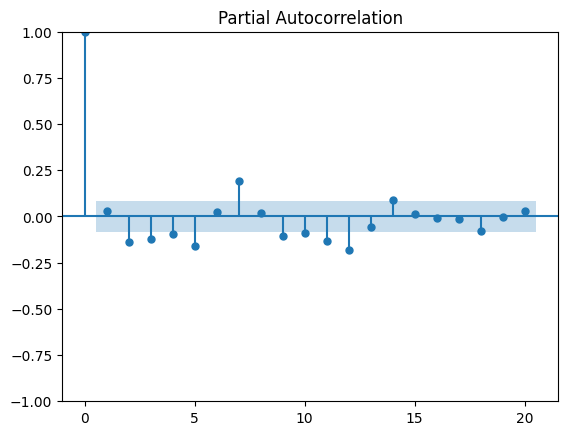

In [639]:
acf = plot_acf(ts_diff, lags=20)
pacf = plot_pacf(ts_diff, lags=20)

#### Interpreting p,d,q from the above plots.
1. ##### For value of 'p' we see the PACF plot, we can see that at 5 the correlation value is significant, so we use 4 or 5 for our model.
2. ##### For value of 'q' we look at the ACF plot, there are 3 lags before we observe the first insignificant value at lag 4, so we choose q=3
3. ##### Our time series became stationary after one differencing so we choose d=1

#### ARIMA Model

In [640]:
def performance(actual, predicted):
    """Calculates performance metrics for the predictions."""
    print('MAE :', round(mae(actual, predicted), 3))
    print('RMSE :', round(mse(actual, predicted)**0.5, 3))
    print('MAPE:', round(mape(actual, predicted), 3))

In [641]:
# Splitting the data for training and testing.

train = ts_data[:-20]
test = ts_data[-20:]

In [642]:
test = pd.DataFrame(test)
test.head()

,en
index,
2016-12-12,5194
2016-12-13,4935
2016-12-14,5185
2016-12-15,4711
2016-12-16,4450


MAE : 506.885
RMSE : 679.228
MAPE: 0.089


<Axes: xlabel='index'>

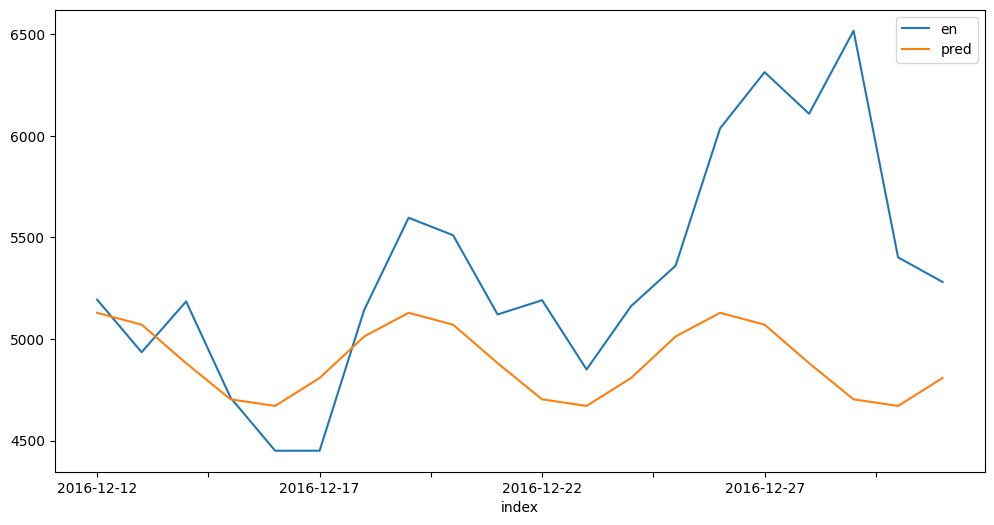

In [643]:
model_ARIMA = SARIMAX(train, order=(4, 1, 3))
model_ARIMA_fitted = model_ARIMA.fit(disp=0)

test['pred'] = model_ARIMA_fitted.forecast(steps=20)

performance(test['en'], test['pred'])
test.plot(figsize=(12, 6))

#### SARIMA Model

MAE : 298.982
RMSE : 452.834
MAPE: 0.053


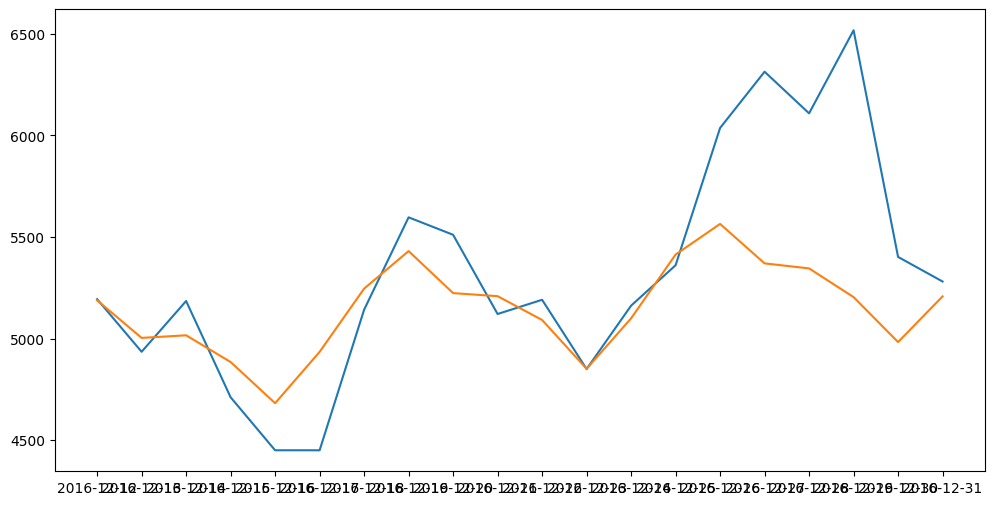

In [644]:
model_SARIMA = SARIMAX(train, order=(4, 1, 3), seasonal_order=(1, 1, 1, 7))
model_SARIMA_fitted = model_SARIMA.fit(disp=0)

test['pred_sarima'] = model_SARIMA_fitted.forecast(steps=20)

performance(test['en'], test['pred_sarima'])
plt.figure(figsize=(12, 6))
plt.plot(test[['en', 'pred_sarima']])
plt.show()

#### SARIMAX Model

In [645]:
# Getting the exogenous variable

exog = pd.read_csv('/Users/farazahmed/Downloads/Exog_Campaign_eng')

In [646]:
exog.shape

(550, 1)

In [647]:
exog.head()

,Exog
0,0
1,0
2,0
3,0
4,0


In [648]:
print(exog.value_counts())

Exog
0       496
1        54
Name: count, dtype: int64


In [649]:
# Checking for nulls.
print(exog.isna().sum())

Exog    0
dtype: int64


In [650]:
english = english.reset_index()
english.head()

,index,en
0,2015-07-01,3767
1,2015-07-02,3755
2,2015-07-03,3565
3,2015-07-04,3712
4,2015-07-05,3833


In [651]:
df_exog = english.join(exog)
df_exog.head()

,index,en,Exog
0,2015-07-01,3767,0
1,2015-07-02,3755,0
2,2015-07-03,3565,0
3,2015-07-04,3712,0
4,2015-07-05,3833,0


In [652]:
print(df_exog['Exog'].value_counts())

Exog
0    496
1     54
Name: count, dtype: int64


In [653]:
df_exog.set_index('index', inplace=True)
df_exog.head()

,en,Exog
index,,
2015-07-01,3767,0
2015-07-02,3755,0
2015-07-03,3565,0
2015-07-04,3712,0
2015-07-05,3833,0


In [654]:
train_SARIMAX = df_exog[:-20]
test_SARIMAX = df_exog[-20:]

In [655]:
start = len(train_SARIMAX)
end = len(train_SARIMAX) + len(test_SARIMAX) - 1

In [669]:
model_SARIMAX = SARIMAX(train_SARIMAX['en'], order=(4, 1, 3), seasonal_order=(2, 1, 2, 7), exog=train_SARIMAX['Exog'])
model_SARIMAX_fitted = model_SARIMAX.fit(disp=0)

predictions = model_SARIMAX_fitted.predict(exog=test_SARIMAX['Exog'], start=start, end=end)

performance(test_SARIMAX['en'], predictions)


MAE : 196.317
RMSE : 249.714
MAPE: 0.037


In [670]:
print(predictions)

2016-12-12    5225.297386
2016-12-13    5051.347489
2016-12-14    4892.936798
2016-12-15    4837.600048
2016-12-16    4621.918527
2016-12-17    4869.106034
2016-12-18    5177.954693
2016-12-19    5361.748324
2016-12-20    5167.561807
2016-12-21    5043.616571
2016-12-22    4955.513637
2016-12-23    4789.612545
2016-12-24    5034.353690
2016-12-25    5342.366030
2016-12-26    5530.846921
2016-12-27    6341.792739
2016-12-28    6243.876816
2016-12-29    6134.635735
2016-12-30    4913.295539
2016-12-31    5187.074632
Freq: D, Name: predicted_mean, dtype: float64


In [671]:
test_SARIMAX_1 = test_SARIMAX.reset_index()
test_SARIMAX_1.head()

,index,en,Exog
0,2016-12-12,5194,0
1,2016-12-13,4935,0
2,2016-12-14,5185,0
3,2016-12-15,4711,0
4,2016-12-16,4450,0


In [672]:
new_df = pd.concat([test_SARIMAX_1, pd.DataFrame(predictions)], axis=1)
new_df.head()

,index,en,Exog,predicted_mean
0,2016-12-12,5194.0,0.0,NaN
1,2016-12-13,4935.0,0.0,NaN
2,2016-12-14,5185.0,0.0,NaN
3,2016-12-15,4711.0,0.0,NaN
4,2016-12-16,4450.0,0.0,NaN


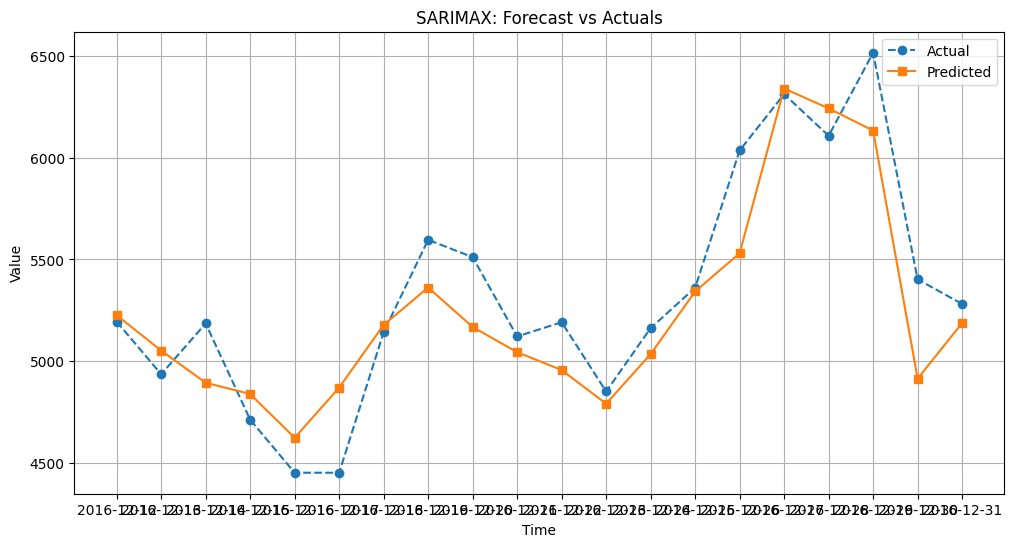

In [673]:
plt.figure(figsize=(12, 6))

# Plot actual values
plt.plot(test_SARIMAX.index, test_SARIMAX['en'], label='Actual', marker='o', linestyle='dashed')

# Plot predicted values
plt.plot(test_SARIMAX.index, predictions, label='Predicted', marker='s')

plt.xlabel('Time')
plt.ylabel('Value')
plt.title('SARIMAX: Forecast vs Actuals')
plt.legend()
plt.grid(True)

plt.show()


In [674]:
data = {
    "Model": ["ARIMA", "SARIMA", "SARIMAX"],
    "MAE": [506.885, 298.982, 196.317],
    "RMSE": [679.228, 452.834, 249.714],
    "MAPE": [0.089, 0.053, 0.037]
}

df = pd.DataFrame(data)
print(df)

     Model      MAE     RMSE   MAPE
0    ARIMA  506.885  679.228  0.089
1   SARIMA  298.982  452.834  0.053
2  SARIMAX  196.317  249.714  0.037


From the table, SARIMAX performs the best among the three models as it has the lowest Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and Mean Absolute Percentage Error (MAPE). This indicates that SARIMAX provides the most accurate predictions, likely due to its ability to incorporate exogenous variables. SARIMA outperforms ARIMA by capturing seasonality, leading to improved accuracy. ARIMA, which does not account for seasonality or external factors, performs the worst.

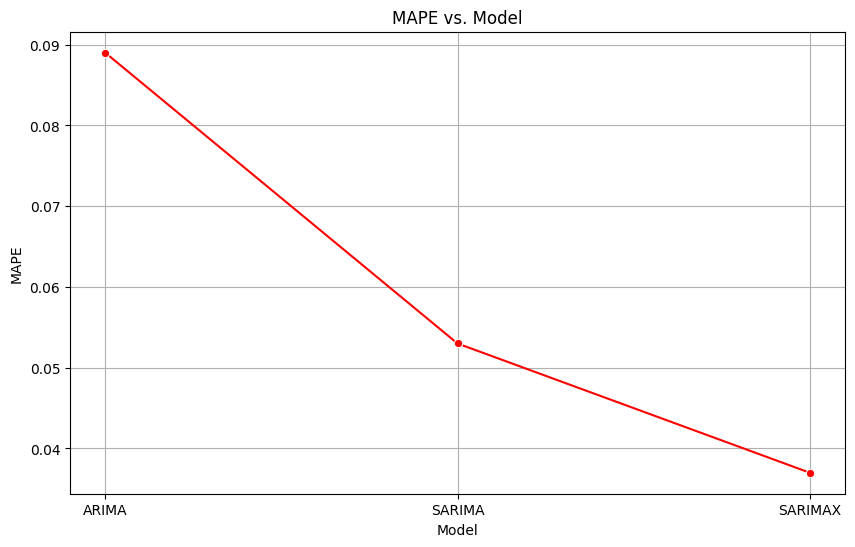

In [681]:
# Model performance comparison

plt.figure(figsize=(10, 6))
sns.lineplot(x='Model', y='MAPE', data=data, marker='o', color='r')
plt.title('MAPE vs. Model')
plt.grid(True)
plt.show()